# Image Complexity Metrics (Entropy, Edge Density, Distinct Colors, Texture)

This notebook computes several **image complexity** proxies on an ImageNet-style folder (or any folder of images):

1. **Entropy (Shannon, grayscale)** → pixel intensity unpredictability (0–8 bits for 8-bit grayscale)
2. **Edge density (Canny)** → fraction of pixels that are edges
3. **Distinct colors (quantized)** → palette richness (robust to JPEG noise by quantization)
4. **Texture statistics (GLCM)** → contrast, homogeneity, energy, correlation

At the top, set:
- `IMG_DIR`: folder containing images (recursively scanned)
- `N_IMAGES`: how many images to include in the analysis
- `IMAGE_IDX`: which image (within the selected set) to visualize in each block


In [55]:
# If needed, install deps (uncomment and run once)
# !pip install pillow numpy opencv-python scikit-image matplotlib

from pathlib import Path
import random
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import cv2
import pandas as pd

from skimage.feature import graycomatrix, graycoprops


In [56]:
# =========================
# 0) CONFIG (edit these)
# =========================
IMG_DIR = Path("../benchmarks/vggnet16_benchmark2022/segmented_outputs/object")
out_csv = Path("csvs/object_complexity_metrics.csv")
N_IMAGES = 1000                       # <-- how many images to analyze (None = ALL)

# Image extensions to include
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tif", ".tiff"}


In [57]:
# =========================
# 1) Collect image paths
# =========================

all_files = [p for p in IMG_DIR.rglob("*") if p.is_file() and p.suffix.lower() in IMAGE_EXTS]
print("Found images:", len(all_files))

if len(all_files) == 0:
    raise RuntimeError("No images found. Check IMG_DIR and extensions.")

sample_files = sorted(all_files)
print("Using images:", len(sample_files))


Found images: 1000
Using images: 1000


In [58]:
# =========================
# 2) Load + display selected image
# =========================
def load_rgb_gray(path: Path):
    rgb = np.array(Image.open(path).convert("RGB"))
    gray = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)  # uint8 0..255
    return rgb, gray

def show_image(rgb, title=""):
    plt.figure(figsize=(5, 5))
    plt.imshow(rgb)
    plt.axis("off")
    plt.title(title)
    plt.show()

## Metric 1 — Entropy (pixel unpredictability)

**What it measures:** How spread-out the grayscale intensity distribution is.

- **0 bits** → all pixels identical (very simple)
- **8 bits** → perfectly uniform distribution across 256 levels (very complex/unpredictable)

Natural images often fall around ~4–7 bits.


In [59]:
def shannon_entropy_gray(gray_u8: np.ndarray) -> float:
    hist = np.bincount(gray_u8.ravel(), minlength=256).astype(np.float64)
    p = hist / hist.sum()
    p = p[p > 0]  # avoid log(0)
    ent = -np.sum(p * np.log2(p))
    return float(ent)

# rows = []
# for img_path in all_files:
#     _, gray = load_rgb_gray(img_path)
#     ent = shannon_entropy_gray(gray)
#     rows.append({
#         "image": img_path.name,
#         "entropy": ent
#     })

# df = pd.DataFrame(rows)
# df.to_csv("image_entropy.csv", index=False)

# print("Saved image_entropy.csv")


## Metric 2 — Edge Density (Canny)

**What it measures:** Fraction of pixels flagged as edges by Canny.
This captures boundary/structure density (often correlates with clutter/detail).

Keep the thresholds fixed across your dataset for fair comparisons.


In [60]:
def edge_density(gray_u8: np.ndarray, low=80, high=160):
    edges = cv2.Canny(gray_u8, low, high)  # edges are 255, non-edges 0
    edge_pixels = int(np.sum(edges > 0))
    density = edge_pixels / edges.size
    return float(density), edge_pixels, edges



# rows = []
# for img_path in all_files:
#     _, gray = load_rgb_gray(img_path)
#     dens, edge_pixels, edges = edge_density(gray, low=80, high=160)
#     rows.append({
#         'path': img_path.name,
#         'density': dens,
#         'edge_pixels': edge_pixels,
#     })

# df = pd.DataFrame(rows)
# df.to_csv("image_edge_density.csv", index=False)   
# print("Saved image_edge_density.csv") 



## Metric 3 — Distinct Colors (Quantized)

**What it measures:** Approximate palette richness.
Raw “unique RGB colors” is overly sensitive to JPEG noise, so we **quantize** RGB first.

- `levels=16` means each channel is binned into 16 values → at most 4096 quantized colors.


In [61]:
def distinct_colors_quantized(rgb_u8: np.ndarray, levels=16) -> int:
    q = (rgb_u8.astype(np.uint16) * levels) // 256  # 0..levels-1 per channel
    packed = q[..., 0] * (levels**2) + q[..., 1] * levels + q[..., 2]
    return int(np.unique(packed.reshape(-1)).size)

# rows = []
# for img_path in all_files:
#     rgb, _ = load_rgb_gray(img_path)
#     n_colors = distinct_colors_quantized(rgb, levels=16)
#     rows.append({
#         'path': img_path.name,
#         'distinct_colors_16levels': n_colors,
#     })

# df = pd.DataFrame(rows)
# df.to_csv("image_distinct_colors_16levels.csv", index=False)   
# print("Saved image_distinct_colors_16levels.csv") 

## Metric 4 — Texture Statistics (GLCM)

**What it measures:** Local texture patterns based on how grayscale intensities co-occur.

We compute **GLCM** features averaged across multiple angles and distances:
- **contrast**: intensity variation (higher → rougher texture)
- **homogeneity**: smoothness (higher → smoother)
- **energy**: uniformity/repetition (higher → more regular)
- **correlation**: linear dependencies in intensity patterns


In [62]:
def glcm_texture_features(gray_u8: np.ndarray, levels=32, distances=(1,2), angles=(0, np.pi/4, np.pi/2, 3*np.pi/4)):
    g = (gray_u8.astype(np.uint16) * levels) // 256  # 0..levels-1
    glcm = graycomatrix(
        g, distances=distances, angles=angles,
        levels=levels, symmetric=True, normed=True
    )
    feats = {}
    for prop in ["contrast", "homogeneity", "energy", "correlation"]:
        vals = graycoprops(glcm, prop)
        feats[prop] = float(vals.mean())
    return feats

# rows = []
# for img_path in all_files:
#     _, gray = load_rgb_gray(img_path)
#     tex = glcm_texture_features(gray, levels=32)
#     rows.append({
#         'path': img_path.name,
#         'contrast': tex['contrast'],
#         'homogeneity': tex['homogeneity'],
#         'energy': tex['energy'],
#         'correlation': tex['correlation'],
#     })

# df = pd.DataFrame(rows)
# df.to_csv("image_glcm_features.csv", index=False)   
# print("Saved image_glcm_features.csv") 

In [63]:
import pandas as pd

def compute_metrics_for_path(path: Path):
    rgb, gray = load_rgb_gray(path)
    ent = shannon_entropy_gray(gray)
    dens, edge_pixels, _ = edge_density(gray, low=80, high=160)
    ncol = distinct_colors_quantized(rgb, levels=16)
    tex = glcm_texture_features(gray, levels=32)
    return {
        "path": str(path),
        "name": path.name,
        "entropy_bits": ent,
        "edge_density": dens,
        "edge_pixels": edge_pixels,
        "distinct_colors_q16": ncol,
        "glcm_contrast": tex["contrast"],
        "glcm_homogeneity": tex["homogeneity"],
        "glcm_energy": tex["energy"],
        "glcm_correlation": tex["correlation"],
    }

rows = []
for p in all_files:
    rows.append(compute_metrics_for_path(p))

df = pd.DataFrame(rows)

# Composite score (simple): z-score entropy + edge_density + distinct_colors + contrast - homogeneity - energy
# Rationale: more detail → higher entropy/edges/colors/contrast; smoother/repetitive textures lower complexity.
for col in ["entropy_bits", "edge_density", "distinct_colors_q16", "glcm_contrast", "glcm_homogeneity", "glcm_energy"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

def zscore(s):
    s = s.astype(float)
    return (s - s.mean()) / (s.std(ddof=0) + 1e-9)

df["complexity_score"] = (
    zscore(df["entropy_bits"]) +
    zscore(df["edge_density"]) +
    zscore(df["distinct_colors_q16"]) +
    zscore(df["glcm_contrast"]) -
    zscore(df["glcm_homogeneity"]) -
    zscore(df["glcm_energy"])
)

df_sorted = df.sort_values("complexity_score", ascending=False).reset_index(drop=True)
df_sorted.head(10)


,path,name,entropy_bits,edge_density,edge_pixels,distinct_colors_q16,glcm_contrast,glcm_homogeneity,glcm_energy,glcm_correlation,complexity_score
0,../benchmarks/vggnet16_benchmark2022/segmented...,n04462240_toyshop.JPEG,7.279710,0.321807,16147,1547,76.458706,0.339735,0.166450,0.555667,14.087275
1,../benchmarks/vggnet16_benchmark2022/segmented...,n04005630_prison.JPEG,7.579017,0.301399,15123,1142,86.565040,0.365952,0.078846,0.505164,13.381475
2,../benchmarks/vggnet16_benchmark2022/segmented...,n02256656_cicada.JPEG,6.773729,0.270588,13577,501,160.880134,0.503489,0.180963,0.481004,11.190036
3,../benchmarks/vggnet16_benchmark2022/segmented...,n03188531_diaper.JPEG,7.692128,0.230588,11570,1560,33.260740,0.423390,0.077827,0.708029,11.037837
4,../benchmarks/vggnet16_benchmark2022/segmented...,n03207743_dishrag.JPEG,7.515578,0.353276,17726,998,17.480712,0.304371,0.063747,0.762372,10.380929
5,../benchmarks/vggnet16_benchmark2022/segmented...,n09256479_coral_reef.JPEG,7.131083,0.247788,12433,829,95.858364,0.444437,0.117893,0.578549,10.250939
6,../benchmarks/vggnet16_benchmark2022/segmented...,n02870880_bookcase.JPEG,7.677468,0.281669,14133,652,75.586012,0.393436,0.099724,0.630671,10.106022
7,../benchmarks/vggnet16_benchmark2022/segmented...,n02108089_boxer.JPEG,7.414233,0.318459,15979,641,67.726542,0.367672,0.122413,0.621535,9.889297
8,../benchmarks/vggnet16_benchmark2022/segmented...,n13037406_gyromitra.JPEG,7.629019,0.244380,12262,987,58.125261,0.446870,0.081429,0.583543,9.753293
9,../benchmarks/vggnet16_benchmark2022/segmented...,n02051845_pelican.JPEG,7.082836,0.283203,14210,731,86.165411,0.425197,0.143390,0.501274,9.720566


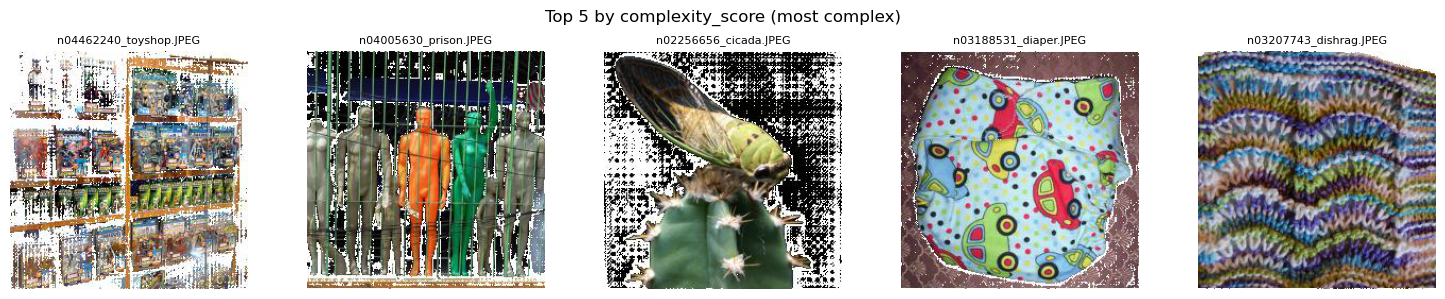

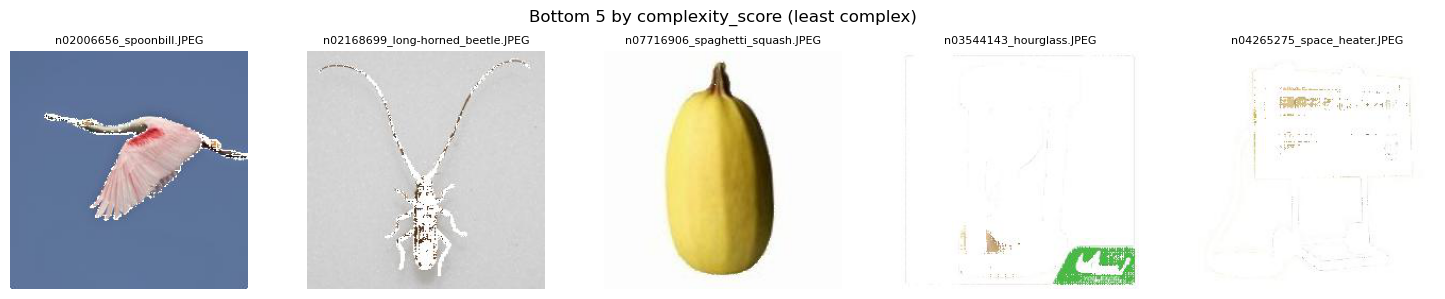

In [64]:
# Show 5 most complex + 5 least complex (by the composite score)

def show_gallery(paths, title):
    n = len(paths)
    cols = min(5, n)
    rows = int(np.ceil(n / cols))
    plt.figure(figsize=(cols * 3, rows * 3))
    for i, p in enumerate(paths):
        rgb, _ = load_rgb_gray(Path(p))
        ax = plt.subplot(rows, cols, i + 1)
        ax.imshow(rgb)
        ax.set_title(Path(p).name, fontsize=8)
        ax.axis("off")
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

top5 = df_sorted.head(5)["path"].tolist()
bot5 = df_sorted.tail(5)["path"].tolist()

show_gallery(top5, "Top 5 by complexity_score (most complex)")
show_gallery(bot5, "Bottom 5 by complexity_score (least complex)")


In [65]:
# Save results (CSV) so you can analyze/categorize further
df_sorted.to_csv(out_csv, index=False)
print("Saved:", out_csv.resolve())


Saved: /Users/zd3504phd/Desktop/XAIV/analysis/csvs/object_complexity_metrics.csv
